# Momentum's Regional Problem — Part 2: Does Value Rescue the Factor?

Part 1 left one unresolved puzzle: **the Japanese momentum premium is ≈ zero.** A factor that pays a premium in North America, Europe, and Asia ex Japan simply doesn't show up in Japan.

This part reframes the question. Not *"why does momentum fail in Japan?"* but *"does anything rescue the factor there?"* The candidate is **value**

**This notebook — data step.** Download the **Value factor (`HML`)** and **Momentum factor (`WML`)** for the four regions from the [Ken French Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html) and assemble them into a single pandas DataFrame indexed by month-end date:

- North America
- Europe
- Asia ex Japan
- Japan

In [1]:
# Auto-reload edited modules so changes in src/ take effect without a kernel restart.
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Make the project root importable so `from src...` works from the notebooks/ folder.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "ken_french.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ken_french import REGIONS, load_all_regions

# Cache the downloaded CSVs here (gitignored).
DATA_DIR = PROJECT_ROOT / "data" / "ken_french"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Show floats with 2 decimals for readable tables.
pd.set_option("display.float_format", lambda x: f"{x:8.2f}")

## Download the Value and Momentum factors

The shared loader (`src/ken_french.py`) already merges each region's 3-factor file (which contains `HML`, the **value** factor) with its momentum file (`WML`). We download all four regions, then keep only the two columns this part cares about:

| Column | Meaning |
|--------|---------|
| `HML`  | Value factor — High minus Low book-to-market |
| `WML`  | Momentum factor — Winners minus Losers |

All returns are monthly, in **percent**.

In [2]:
# Download + parse all four regions (each already includes HML and WML).
regional_factors = load_all_regions()

# Keep only Value (HML) and Momentum (WML), renamed for clarity.
value_momentum = {
    region_key: (
        df[["HML", "WML"]]
        .rename(columns={"HML": "Value", "WML": "Momentum"})
    )
    for region_key, df in regional_factors.items()
}

for region_key, df in value_momentum.items():
    label = REGIONS[region_key]["label"]
    print(f"{label:<16} rows={len(df):>4}  {df.index.min().date()} to {df.index.max().date()}")

North America    rows= 428  1990-11-30 to 2026-06-30
Europe           rows= 428  1990-11-30 to 2026-06-30
Asia ex Japan    rows= 428  1990-11-30 to 2026-06-30
Japan            rows= 428  1990-11-30 to 2026-06-30


## Assemble one date-indexed panel

We concatenate the four regions side by side into a single DataFrame indexed by month-end date, with **MultiIndex columns** `(region, factor)`. This makes it easy to slice either a single region (`panel["japan"]`) or a single factor across regions (`panel.xs("Value", axis=1, level=1)`).

In [3]:
panel = pd.concat(value_momentum, axis=1)
panel.columns.names = ["region", "factor"]
panel.index.name = "date"

print(f"panel shape: {panel.shape[0]} months x {panel.shape[1]} series")
panel.head()

panel shape: 428 months x 8 series


region     north_america            europe          asia_ex_japan           \
factor             Value Momentum    Value Momentum         Value Momentum   
date                                                                         
1990-11-30         -1.79    -2.59     0.57     2.45         -0.77     2.77   
1990-12-31         -1.08    -0.83     0.26     0.52         -1.02     2.51   
1991-01-31         -0.05    -2.63    -0.03    -1.25          1.34     1.28   
1991-02-28         -0.83    -2.21     0.66    -7.50         -1.60    -2.88   
1991-03-31         -2.99     3.16    -0.27     0.23          1.80     2.64   

region        japan           
factor        Value Momentum  
date                          
1990-11-30    -0.20     1.50  
1990-12-31    -3.61    -8.04  
1991-01-31     0.24     0.46  
1991-02-28     0.80   -15.23  
1991-03-31     0.40     1.45

## Summary statistics — Value, Momentum & 50/50 Combo

**Article exhibit — Table 1:** Value, Momentum, and 50/50 Combo summary statistics per region (whole period).

Standalone performance of each factor, per region. Both `HML` (Value) and `WML` (Momentum) are **self-financing long/short** portfolios, so their returns are already excess returns — no risk-free adjustment.

| Metric | Definition |
|--------|------------|
| **Ann. Mean (%)** | mean(monthly) × 12 |
| **Ann. Vol (%)** | std(monthly) × √12 |
| **Sharpe** | Ann. Mean / Ann. Vol |
| **t-stat** | mean / (std / √n) — is the average return reliably ≠ 0? |
| **Max DD (%)** | deepest drawdown of the compounded equity curve |

Watch Japan: Momentum's t-stat should be indistinguishable from zero (Part 1's puzzle), while Value should stand up.

In [4]:
def factor_stats(returns_pct: pd.Series) -> dict:
    """Annualized performance stats for one monthly return series (in %)."""
    r = returns_pct.dropna()
    n = r.count()
    monthly_mean, monthly_vol = r.mean(), r.std()

    # Annualize: mean scales by 12, volatility by sqrt(12) (returns assumed independent).
    ann_mean = monthly_mean * 12
    ann_vol = monthly_vol * (12 ** 0.5)

    # Drawdown of the compounded equity curve vs its running peak.
    equity = (1 + r / 100).cumprod()
    drawdown = (equity / equity.cummax() - 1) * 100

    return {
        "Ann. Mean (%)": ann_mean,
        "Ann. Vol (%)": ann_vol,
        "Sharpe": ann_mean / ann_vol,
        "t-stat": monthly_mean / (monthly_vol / (n ** 0.5)),
        "Max DD (%)": drawdown.min(),
        "Max DD Date": drawdown.idxmin().date(),
    }


# One row per (region, factor); columns are the metrics above.
records = {
    (REGIONS[region_key]["label"], factor): factor_stats(panel[region_key][factor])
    for region_key in REGIONS
    for factor in ["Value", "Momentum"]
}

stats_table = pd.DataFrame(records).T
stats_table.index.names = ["Region", "Factor"]

stats_table.to_csv(DATA_DIR / "value_momentum_stats.csv")
stats_table.round(2)

Ann. Mean (%) Ann. Vol (%)   Sharpe   t-stat  \
Region        Factor                                                  
North America Value             1.81        12.06     0.15     0.90   
              Momentum          6.71        15.70     0.43     2.55   
Europe        Value             4.20         9.01     0.47     2.78   
              Momentum         10.58        13.11     0.81     4.82   
Asia ex Japan Value             7.08        10.49     0.68     4.03   
              Momentum         10.29        14.34     0.72     4.28   
Japan         Value             4.85        10.76     0.45     2.69   
              Momentum          1.50        14.47     0.10     0.62   

                       Max DD (%) Max DD Date  
Region        Factor                           
North America Value        -60.51  2020-09-30  
              Momentum     -49.97  2009-09-30  
Europe        Value        -50.89  2020-10-31  
              Momentum     -45.59  2009-09-30  
Asia ex Japan Value        -28.09  2020-12-31  
              Momentum     -52.81  2000-11-30  
Japan         Value        -46.46  2020-11-30  
              Momentum     -41.96  2012-02-29

## Factor return curves — Value vs Momentum, per region

**Article exhibit — Graph 1:** Growth of $1 — Value vs Momentum, by region (log scale).

One panel per region, each plotting the **cumulative growth of $1** for Value and Momentum. Monthly returns compound geometrically, so growth is `(1 + r/100).cumprod()` — the standard way to visualize a self-financing factor's return.

The **log scale** keeps multi-decade compounding readable (equal vertical distance = equal % move). Watch Japan: Momentum drifts sideways while Value climbs — the setup for the offset argument.

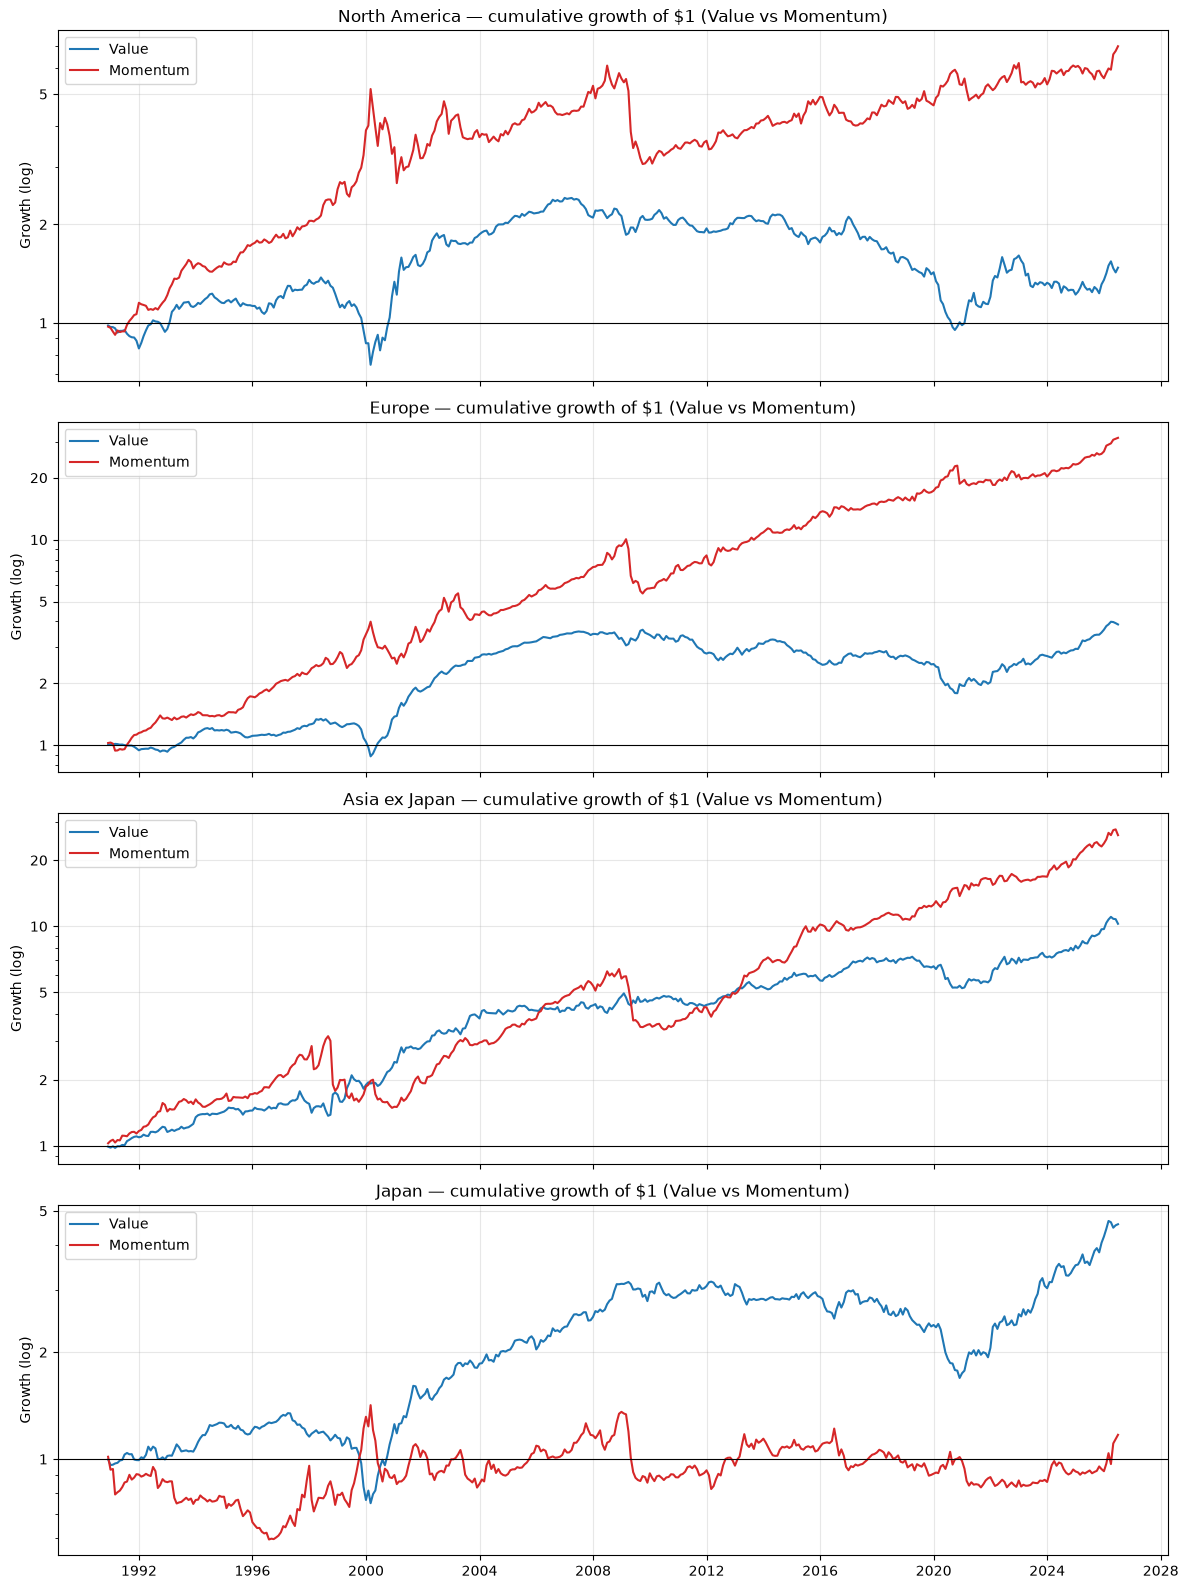

In [5]:
import matplotlib.ticker as mticker  # local import so this cell runs regardless of run order

factor_color = {"Value": "#1f77b4", "Momentum": "#d62728"}

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

for ax, region_key in zip(axes, REGIONS):
    label = REGIONS[region_key]["label"]
    for factor in ["Value", "Momentum"]:
        returns = panel[region_key][factor].dropna()
        growth = (1 + returns / 100).cumprod()
        ax.plot(growth.index, growth, label=factor, color=factor_color[factor])

    ax.set_title(f"{label} — cumulative growth of $1 (Value vs Momentum)")
    ax.set_ylabel("Growth (log)")
    ax.set_yscale("log")  # keeps multi-decade compounding readable
    ax.yaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1, 2, 5)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:g}"))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.axhline(1, color="black", linewidth=0.8)  # break-even: $1 grows to $1
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
panel_path = DATA_DIR / "value_momentum_panel.csv"
panel.to_csv(panel_path)
print(f"saved -> {panel_path.relative_to(PROJECT_ROOT)}")

# Reload check: header spans two rows (region, factor), index is the date.
reloaded = pd.read_csv(panel_path, header=[0, 1], index_col=0, parse_dates=True)
print(f"reloaded shape: {reloaded.shape}")

saved -> data/ken_french/value_momentum_panel.csv
reloaded shape: (428, 8)


## Value correlation across regions

Pearson correlation of monthly **Value (`HML`)** returns between regions. High values mean value tends to pay off (or suffer) at the same time across those markets — i.e. how globally synchronized the value factor is.

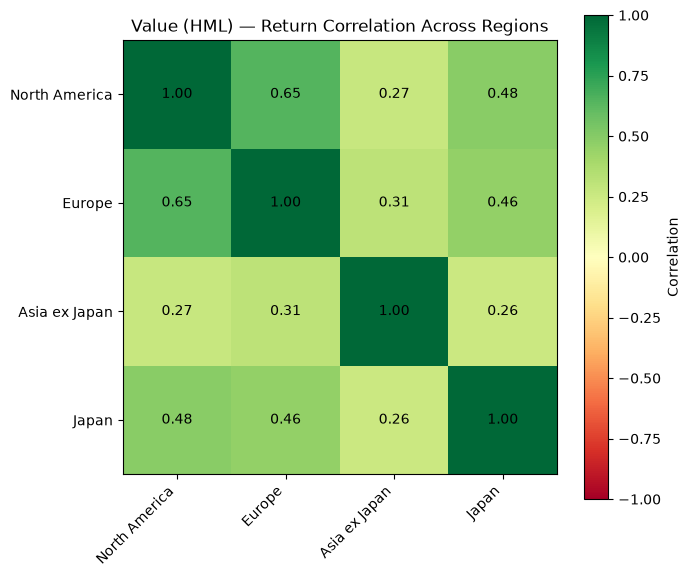

region,North America,Europe,Asia ex Japan,Japan
region,,,,
North America,1.00,0.65,0.27,0.48
Europe,0.65,1.00,0.31,0.46
Asia ex Japan,0.27,0.31,1.00,0.26
Japan,0.48,0.46,0.26,1.00


In [7]:
# Value returns for every region, side by side (columns relabeled to readable names).
value_by_region = panel.xs("Value", axis=1, level="factor").rename(
    columns=lambda region_key: REGIONS[region_key]["label"]
)
value_corr = value_by_region.corr()

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(value_corr, cmap="RdYlGn", vmin=-1, vmax=1)

labels = value_corr.columns
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)

# Annotate each cell with its correlation value.
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{value_corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_title("Value (HML) — Return Correlation Across Regions")
fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

value_corr.round(2)

## Value vs Momentum correlation, by region (whole period)

**Article exhibit — Table 2:** Value–Momentum correlation, by region (whole period).

within each region, how correlated are the **Value** and **Momentum** factors? A **negative** correlation means they offset — when one leg suffers, the other tends to cushion it, so a 50/50 combo is smoother than either alone.



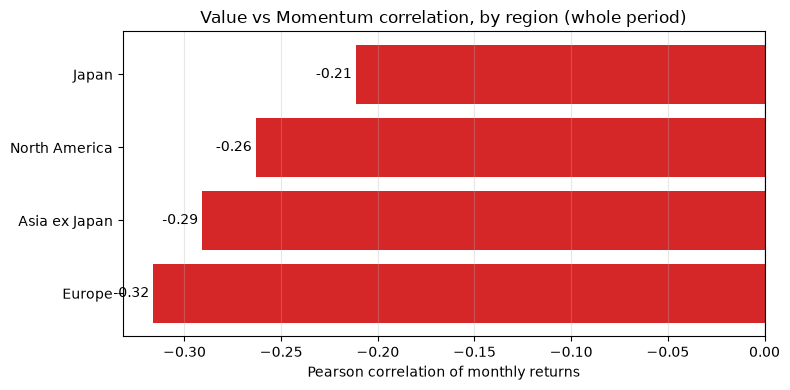

,"corr(Value, Momentum)"
Europe,-0.32
Asia ex Japan,-0.29
North America,-0.26
Japan,-0.21


In [8]:
# Within-region Pearson correlation between the Value and Momentum legs.
vm_corr = pd.Series(
    {
        REGIONS[region_key]["label"]: panel[region_key]["Value"].corr(
            panel[region_key]["Momentum"]
        )
        for region_key in REGIONS
    },
    name="corr(Value, Momentum)",
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ["#d62728" if c < 0 else "#2ca02c" for c in vm_corr]  # red = offsetting
ax.barh(vm_corr.index, vm_corr.values, color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)

for i, c in enumerate(vm_corr.values):
    ax.text(c, i, f" {c:.2f} ", va="center", ha="right" if c < 0 else "left")

ax.set_title("Value vs Momentum correlation, by region (whole period)")
ax.set_xlabel("Pearson correlation of monthly returns")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

vm_corr.round(2).to_frame()

## The 50/50 combo — does value rescue momentum?

**Article exhibit — Table 3:** 50/50 combo — Sharpe vs standalone legs, plus the combo's full stat line (ann. return, vol, t-stat, max DD, max DD date).

For each region we build an equal-weight, monthly-rebalanced **50/50 Value + Momentum** portfolio:

`combo = 0.5 × Value + 0.5 × Momentum`

Both legs are self-financing long/short excess returns (in %), so the equal-weight average is itself an excess return. Because the two legs are negatively correlated, the combo's volatility is lower than the average of its parts — so its **Sharpe can exceed either standalone leg**.

The test for Japan: even though standalone Momentum ≈ 0, the combo should still post a respectable Sharpe — carried by Value, smoothed by the negative correlation.

In [9]:
# Equal-weight, monthly-rebalanced 50/50 Value + Momentum return, per region.
combo_returns = {
    region_key: panel[region_key][["Value", "Momentum"]].mean(axis=1)
    for region_key in REGIONS
}

# Full stats for each region's combo (reuses factor_stats defined above).
combo_stats = pd.DataFrame(
    {REGIONS[rk]["label"]: factor_stats(combo_returns[rk]) for rk in REGIONS}
).T
combo_stats.index.name = "Region"
combo_stats.to_csv(DATA_DIR / "value_momentum_combo_stats.csv")

# Sharpe side by side: does the 50/50 combo beat both standalone legs?
sharpe_compare = pd.DataFrame(
    {
        "Value": {REGIONS[rk]["label"]: factor_stats(panel[rk]["Value"])["Sharpe"] for rk in REGIONS},
        "Momentum": {REGIONS[rk]["label"]: factor_stats(panel[rk]["Momentum"])["Sharpe"] for rk in REGIONS},
        "50/50 Combo": combo_stats["Sharpe"],
    }
)
sharpe_compare.index.name = "Region"

# Table 3: Sharpe for all three legs, plus the 50/50 combo's full stat line.
table3 = sharpe_compare.rename(
    columns={"Value": "Value Sharpe", "Momentum": "Momentum Sharpe", "50/50 Combo": "Combo Sharpe"}
).join(
    combo_stats[["Ann. Mean (%)", "Ann. Vol (%)", "t-stat", "Max DD (%)", "Max DD Date"]].add_prefix("Combo ")
)
table3.to_csv(DATA_DIR / "combo_table3.csv")
table3.round(2)

,Value Sharpe,Momentum Sharpe,Combo Sharpe,Combo Ann. Mean (%),Combo Ann. Vol (%),Combo t-stat,Combo Max DD (%),Combo Max DD Date
Region,,,,,,,,
North America,0.15,0.43,0.50,4.26,8.55,2.98,-31.76,2020-12-31
Europe,0.47,0.81,1.11,7.39,6.68,6.61,-19.20,2010-02-28
Asia ex Japan,0.68,0.72,1.15,8.68,7.55,6.87,-26.35,2009-08-31
Japan,0.45,0.10,0.39,3.18,8.05,2.36,-34.49,2021-08-31


### Combo return curves — Value, Momentum, and 50/50 per region

The 50/50 combo (black, thicker) plotted over its two legs. Look at Japan: the combo should climb steadily even though Momentum (red) goes nowhere — the visual proof that value rescues the factor.

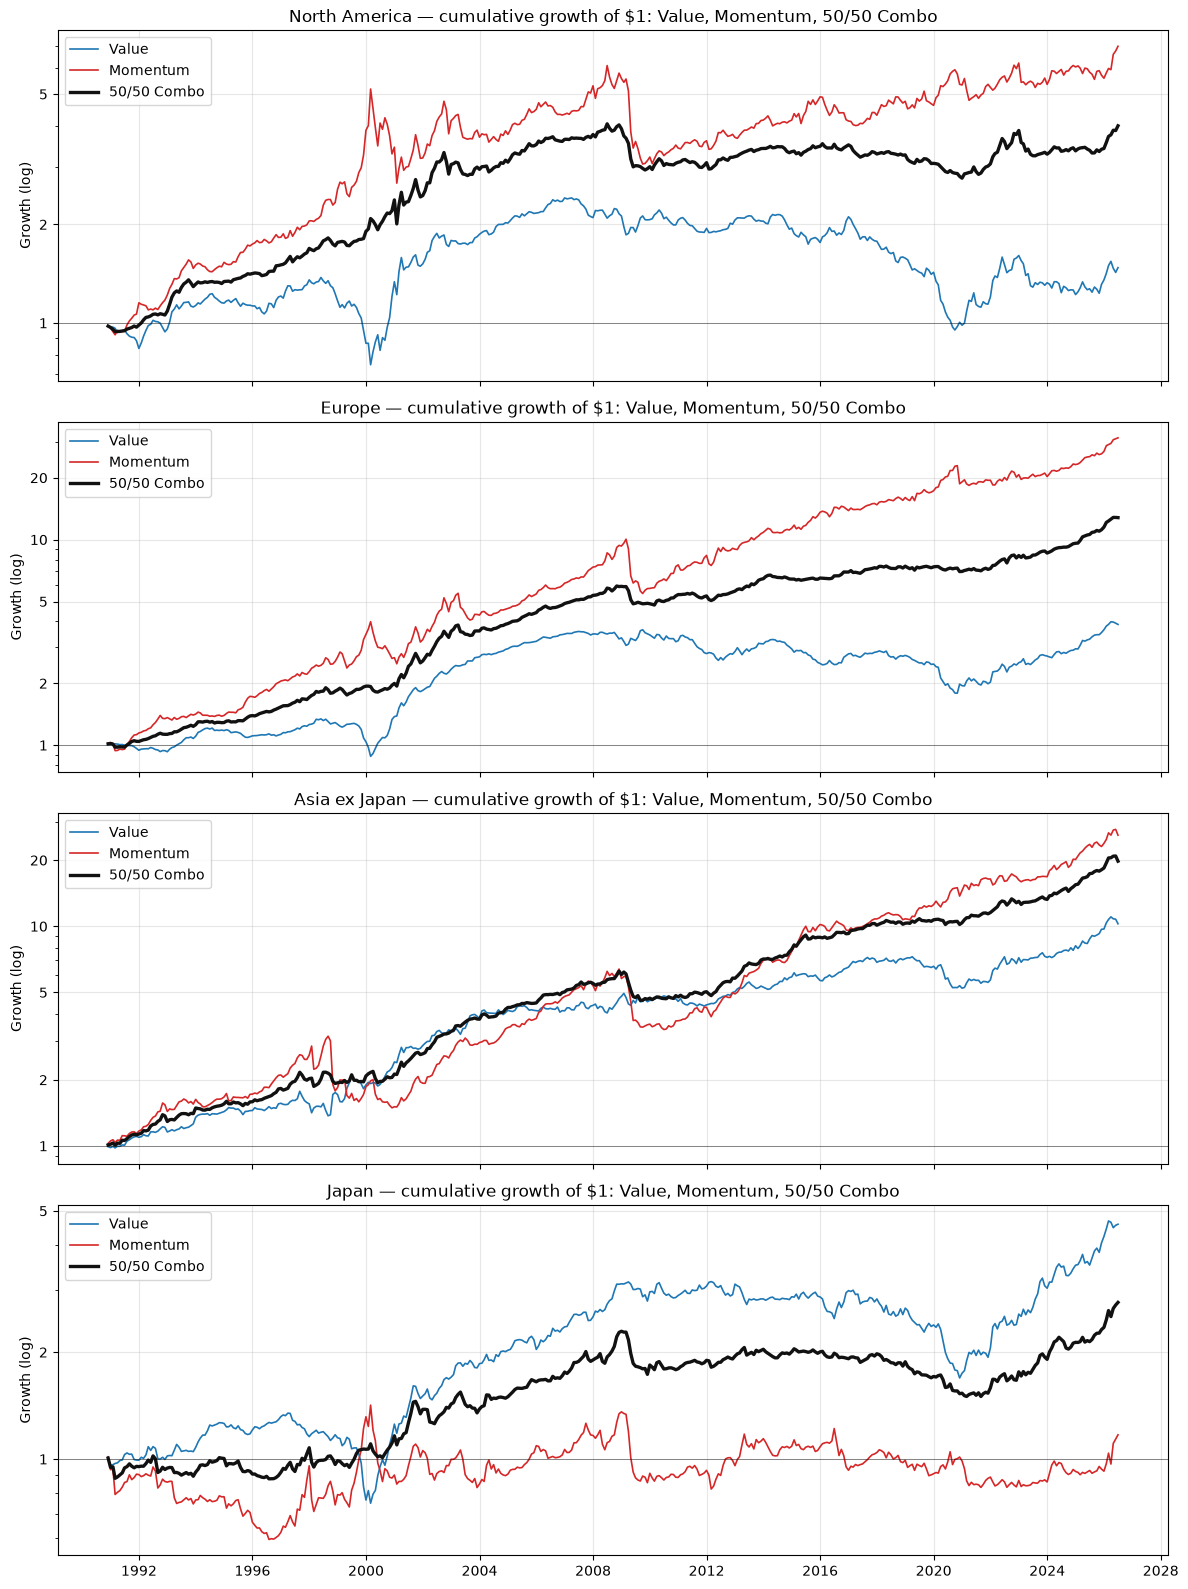

In [10]:
import matplotlib.ticker as mticker  # local import so this cell runs regardless of run order

line_color = {"Value": "#1f77b4", "Momentum": "#d62728", "50/50 Combo": "#111111"}

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

for ax, region_key in zip(axes, REGIONS):
    label = REGIONS[region_key]["label"]
    series = {
        "Value": panel[region_key]["Value"],
        "Momentum": panel[region_key]["Momentum"],
        "50/50 Combo": combo_returns[region_key],
    }
    for name, returns in series.items():
        returns = returns.dropna()
        growth = (1 + returns / 100).cumprod()
        width = 2.4 if name == "50/50 Combo" else 1.2
        ax.plot(growth.index, growth, label=name, color=line_color[name], linewidth=width)

    ax.set_title(f"{label} — cumulative growth of $1: Value, Momentum, 50/50 Combo")
    ax.set_ylabel("Growth (log)")
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1, 2, 5)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:g}"))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.axhline(1, color="black", linewidth=0.6, alpha=0.5)
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Sub-period analysis — is the story stable across regimes?

The whole-period numbers hide *when* each factor worked. We repeat the three core analyses — **stat table**, **Value↔Momentum correlation**, and **cumulative return** — over three non-overlapping regimes:

| Period | Era |
|--------|-----|
| **1990–1999** | Pre-dot-com |
| **2000–2012** | Dot-com bust → GFC → Euro crisis |
| **2013–2026** | QE / growth-and-momentum decade |

This tests whether Japan's momentum weakness (and the value offset) is a permanent structural feature or a regime-dependent one — the seed for Part 3.

In [11]:
PERIODS = {
    "1990-1999": ("1990-01-01", "1999-12-31"),
    "2000-2012": ("2000-01-01", "2012-12-31"),
    "2013-2026": ("2013-01-01", "2026-12-31"),
}


def region_factor_frame(region_key: str, start: str, end: str) -> pd.DataFrame:
    """Value, Momentum, and 50/50 Combo monthly returns for one region over [start, end]."""
    window = panel[region_key].loc[start:end]
    frame = window[["Value", "Momentum"]].copy()
    frame["50/50 Combo"] = window[["Value", "Momentum"]].mean(axis=1)
    return frame


FACTOR_ORDER = ["Value", "Momentum", "50/50 Combo"]

# Quick coverage check so short-window stats are trustworthy.
for pname, (start, end) in PERIODS.items():
    months = len(panel["japan"].loc[start:end])
    print(f"{pname}: {months} months")

1990-1999: 110 months
2000-2012: 156 months
2013-2026: 162 months


## Stat tables by sub-period

Same metrics as the whole-period table (Ann. Mean, Ann. Vol, Sharpe, t-stat, Max DD), now for Value, Momentum, and the 50/50 Combo — one table per regime. Note: t-stats shrink in short windows (fewer months), so read Sharpe as the primary signal here.

In [12]:
# Full stats for every (region, factor) within each period.
period_stats = {}
for pname, (start, end) in PERIODS.items():
    rows = {}
    for region_key in REGIONS:
        frame = region_factor_frame(region_key, start, end)
        for factor in FACTOR_ORDER:
            rows[(REGIONS[region_key]["label"], factor)] = factor_stats(frame[factor])
    table = pd.DataFrame(rows).T
    table.index.names = ["Region", "Factor"]
    period_stats[pname] = table
    table.to_csv(DATA_DIR / f"stats_{pname}.csv")

    print(f"\n{'=' * 70}\n{pname}\n{'=' * 70}")
    print(table.round(2).to_string())

# Compact cross-regime view: Combo Sharpe per region, period over period.
combo_sharpe_by_period = pd.DataFrame(
    {
        pname: {
            region: period_stats[pname].loc[(region, "50/50 Combo"), "Sharpe"]
            for region in [REGIONS[rk]["label"] for rk in REGIONS]
        }
        for pname in PERIODS
    }
)
combo_sharpe_by_period.index.name = "Region"
print(f"\n50/50 Combo Sharpe by period:")
combo_sharpe_by_period.round(2)


1990-1999
                          Ann. Mean (%) Ann. Vol (%)   Sharpe   t-stat Max DD (%) Max DD Date
Region        Factor                                                                         
North America Value               -1.11         9.50    -0.12    -0.35     -37.05  1999-12-31
              Momentum            15.48        11.29     1.37     4.15      -9.87  1999-05-31
              50/50 Combo          7.18         5.30     1.36     4.10      -5.44  1998-11-30
Europe        Value                0.60         6.05     0.10     0.30     -22.65  1999-12-31
              Momentum            14.09         9.74     1.45     4.38     -16.40  1999-04-30
              50/50 Combo          7.34         4.66     1.58     4.77      -7.82  1999-04-30
Asia ex Japan Value                7.78        12.90     0.60     1.83     -22.68  1998-08-31
              Momentum             8.99        19.53     0.46     1.39     -49.75  1999-09-30
              50/50 Combo          8.39         8

,1990-1999,2000-2012,2013-2026
Region,,,
North America,1.36,0.41,0.28
Europe,1.58,0.98,1.17
Asia ex Japan,0.98,1.03,1.47
Japan,0.13,0.57,0.40


## Value ↔ Momentum offset by sub-period

Does the negative value–momentum correlation — the engine of the combo — hold up in every regime, or does it come and go? Rows are regions, columns are periods; more negative (redder) = stronger offset.

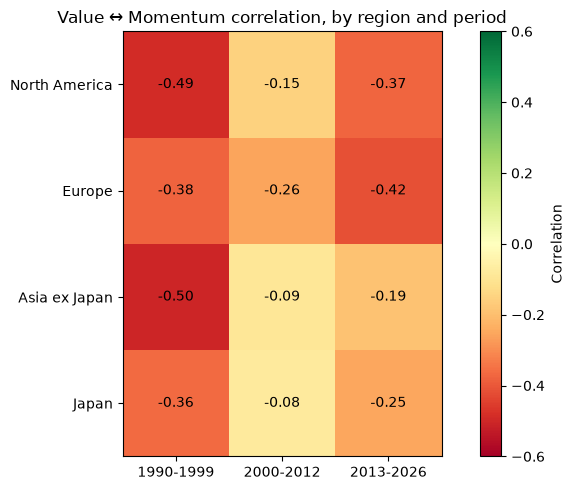

,1990-1999,2000-2012,2013-2026
Region,,,
North America,-0.49,-0.15,-0.37
Europe,-0.38,-0.26,-0.42
Asia ex Japan,-0.50,-0.09,-0.19
Japan,-0.36,-0.08,-0.25


In [13]:
# corr(Value, Momentum) within each region, for each period.
offset_by_period = pd.DataFrame(
    {
        pname: {
            REGIONS[rk]["label"]: (
                panel[rk].loc[start:end]["Value"].corr(panel[rk].loc[start:end]["Momentum"])
            )
            for rk in REGIONS
        }
        for pname, (start, end) in PERIODS.items()
    }
)
offset_by_period.index.name = "Region"
offset_by_period.to_csv(DATA_DIR / "offset_by_period.csv")

fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(offset_by_period, cmap="RdYlGn", vmin=-0.6, vmax=0.6)

ax.set_xticks(range(len(offset_by_period.columns)), offset_by_period.columns)
ax.set_yticks(range(len(offset_by_period.index)), offset_by_period.index)

for i in range(len(offset_by_period.index)):
    for j in range(len(offset_by_period.columns)):
        ax.text(j, i, f"{offset_by_period.iloc[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_title("Value \u2194 Momentum correlation, by region and period")
fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

offset_by_period.round(2)

## Cumulative return by sub-period

A 4×3 grid: **rows are regions, columns are periods**. Each panel rebases $1 at the start of the window and plots Value, Momentum, and the 50/50 Combo. This shows *when* each factor earned its keep — and where the combo (black) delivered the smoothest ride.

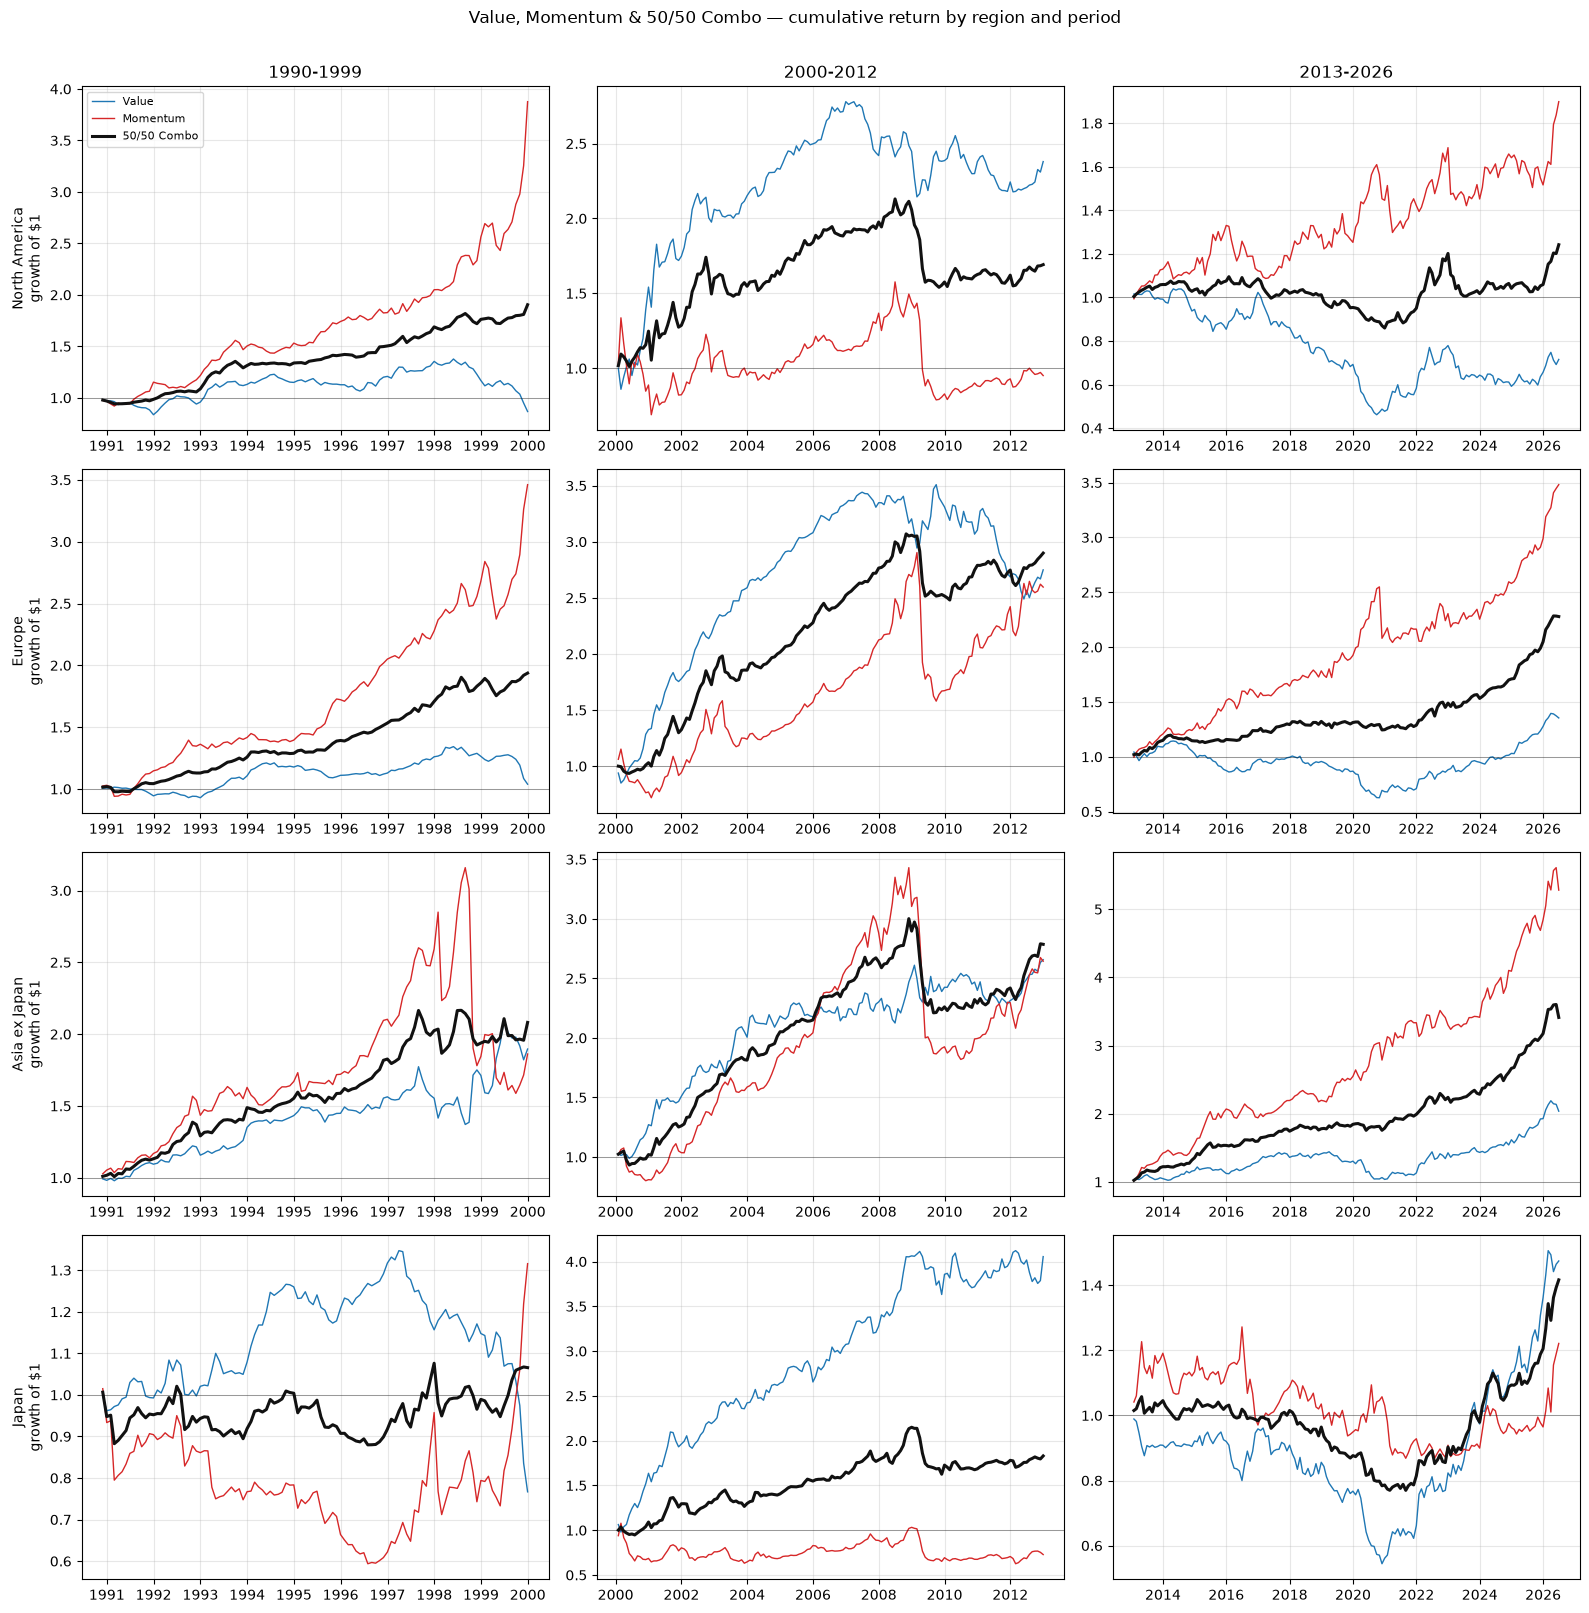

In [14]:
line_color = {"Value": "#1f77b4", "Momentum": "#d62728", "50/50 Combo": "#111111"}

fig, axes = plt.subplots(
    len(REGIONS), len(PERIODS), figsize=(16, 16), sharex=False, sharey=False
)

for row, region_key in enumerate(REGIONS):
    for col, (pname, (start, end)) in enumerate(PERIODS.items()):
        ax = axes[row, col]
        frame = region_factor_frame(region_key, start, end)
        for factor in FACTOR_ORDER:
            growth = (1 + frame[factor].dropna() / 100).cumprod()
            width = 2.2 if factor == "50/50 Combo" else 1.0
            ax.plot(growth.index, growth, label=factor, color=line_color[factor], linewidth=width)

        ax.axhline(1, color="black", linewidth=0.6, alpha=0.4)  # break-even
        ax.grid(alpha=0.3)
        if row == 0:
            ax.set_title(pname)
        if col == 0:
            ax.set_ylabel(f"{REGIONS[region_key]['label']}\ngrowth of $1")
        if row == 0 and col == 0:
            ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Value, Momentum & 50/50 Combo — cumulative return by region and period", y=1.005)
plt.tight_layout()
plt.show()

# Did governance reform change the Japanese value premium?

Part 1 closed on this question. The reform era brought **Abenomics (Dec 2012)** and the **Corporate Governance Code (Jun 2015)** — policies explicitly aimed at improving capital efficiency and shareholder returns, which *should* reward a value strategy.

The data says the opposite. Japan's value premium was strongest in the **pre-reform** 2000–2012 window (Sharpe 1.07, t = 3.87) and **faded to insignificance** through the reform era (2013–2026: Sharpe 0.30, t = 1.10). The rolling view below shows the trajectory continuously, with the two reform milestones marked.

**Article exhibit — Graph 3:** Japan — rolling 36-month annualized factor return. **Table 4** (value premium by sub-period) follows below.

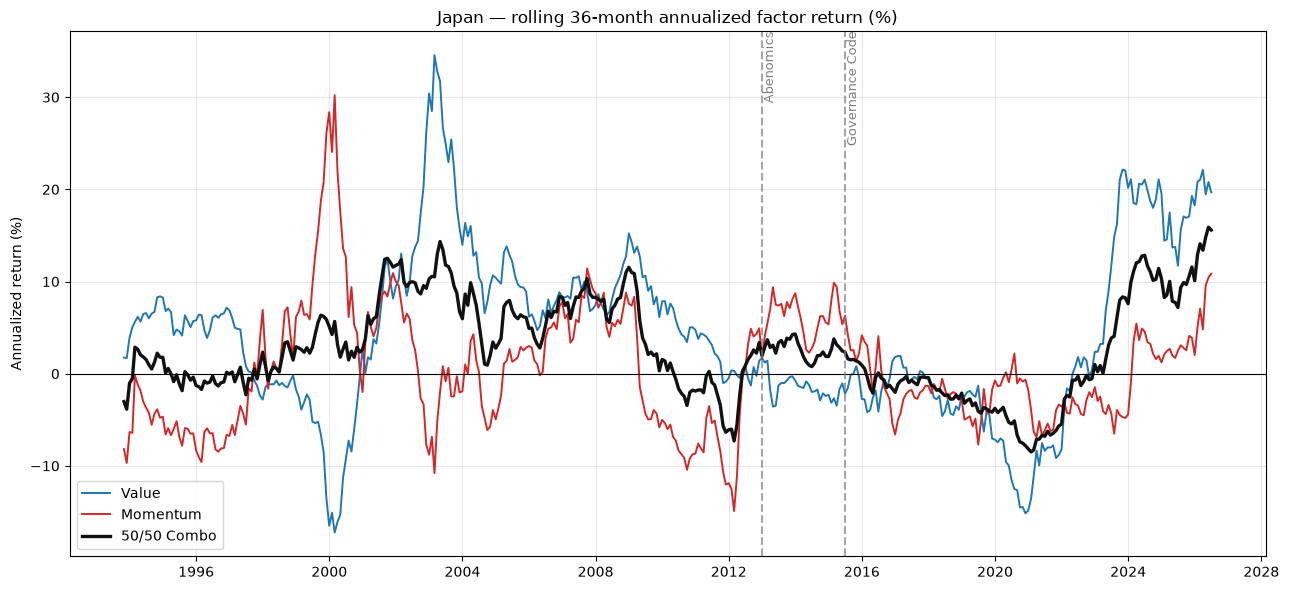

Pre-reform 2000-2012: ann.mean= 11.4%   Sharpe= 1.07   t= 3.87
Reform era 2013-2026: ann.mean=  3.5%   Sharpe= 0.30   t= 1.12


In [15]:
def rolling_annualized(returns_pct: pd.Series, window: int = 36) -> pd.Series:
    """Geometric annualized return over a rolling window, in %."""
    growth = 1 + returns_pct / 100
    window_growth = growth.rolling(window).apply(lambda x: x.prod(), raw=True)
    return (window_growth ** (12 / window) - 1) * 100


japan = panel["japan"]
japan_series = {
    "Value": japan["Value"],
    "Momentum": japan["Momentum"],
    "50/50 Combo": japan[["Value", "Momentum"]].mean(axis=1),
}
line_color = {"Value": "#1f77b4", "Momentum": "#d62728", "50/50 Combo": "#111111"}

fig, ax = plt.subplots(figsize=(13, 6))
for name, series in japan_series.items():
    roll = rolling_annualized(series)
    ax.plot(roll.index, roll, label=name, color=line_color[name],
            linewidth=2.4 if name == "50/50 Combo" else 1.4)

ax.axhline(0, color="black", linewidth=0.8)
for date, note in [("2012-12-31", "Abenomics"), ("2015-06-30", "Governance Code")]:
    marker = pd.Timestamp(date)
    ax.axvline(marker, color="gray", linestyle="--", alpha=0.7)
    ax.text(marker, ax.get_ylim()[1], f" {note}", rotation=90, va="top", ha="left",
            fontsize=9, color="gray")

ax.set_title("Japan — rolling 36-month annualized factor return (%)")
ax.set_ylabel("Annualized return (%)")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Pre- vs post-reform value premium, stated plainly.
for label, (start, end) in {"Pre-reform 2000-2012": ("2000-01-01", "2012-12-31"),
                            "Reform era 2013-2026": ("2013-01-01", "2026-12-31")}.items():
    v = japan["Value"].loc[start:end]
    sharpe = (v.mean() * 12) / (v.std() * 12 ** 0.5)
    t_stat = v.mean() / (v.std() / len(v) ** 0.5)
    print(f"{label}: ann.mean={v.mean() * 12:5.1f}%   Sharpe={sharpe:5.2f}   t={t_stat:5.2f}")

## Value premium by sub-period

**Article exhibit — Table 4:** Value premium by sub-period (annualized return and t-statistic, all regions).

In [16]:
# Table 4: value premium (HML) by sub-period — annualized return and t-stat, all regions.
table4 = pd.concat(
    {
        pname: pd.DataFrame(
            {REGIONS[rk]["label"]: factor_stats(panel[rk]["Value"].loc[start:end]) for rk in REGIONS}
        ).T[["Ann. Mean (%)", "t-stat"]]
        for pname, (start, end) in PERIODS.items()
    },
    axis=1,
)
table4.index.name = "Region (Value factor)"
table4.to_csv(DATA_DIR / "value_premium_by_period.csv")
table4.round(2)

1990-1999              2000-2012           \
                      Ann. Mean (%)   t-stat Ann. Mean (%)   t-stat   
Region (Value factor)                                                 
North America                 -1.11    -0.35          7.58     2.02   
Europe                         0.60     0.30          8.27     3.06   
Asia ex Japan                  7.78     1.83          8.01     2.96   
Japan                         -2.46    -0.82         11.37     3.87   

                          2013-2026           
                      Ann. Mean (%)   t-stat  
Region (Value factor)                         
North America                 -1.77    -0.54  
Europe                         2.73     1.02  
Asia ex Japan                  5.72     2.25  
Japan                          3.55     1.12

## Drawdowns — does the combo actually ride smoother?

**Article exhibits — Graph 4:** Factor drawdowns (underwater), by region. **Table 5:** Maximum drawdown, Value / Momentum / Combo.

Part 1 showed momentum's crash-*recovery* asymmetry (its worst losses arrive in the rebound). Here we put Value, Momentum, and the 50/50 Combo underwater together, per region. The claim to check: the combo's drawdowns should be **shallower** than either leg — the offset cushioning directional pain — and the **2020 value crash** should be visible in the blue line but muted in black.

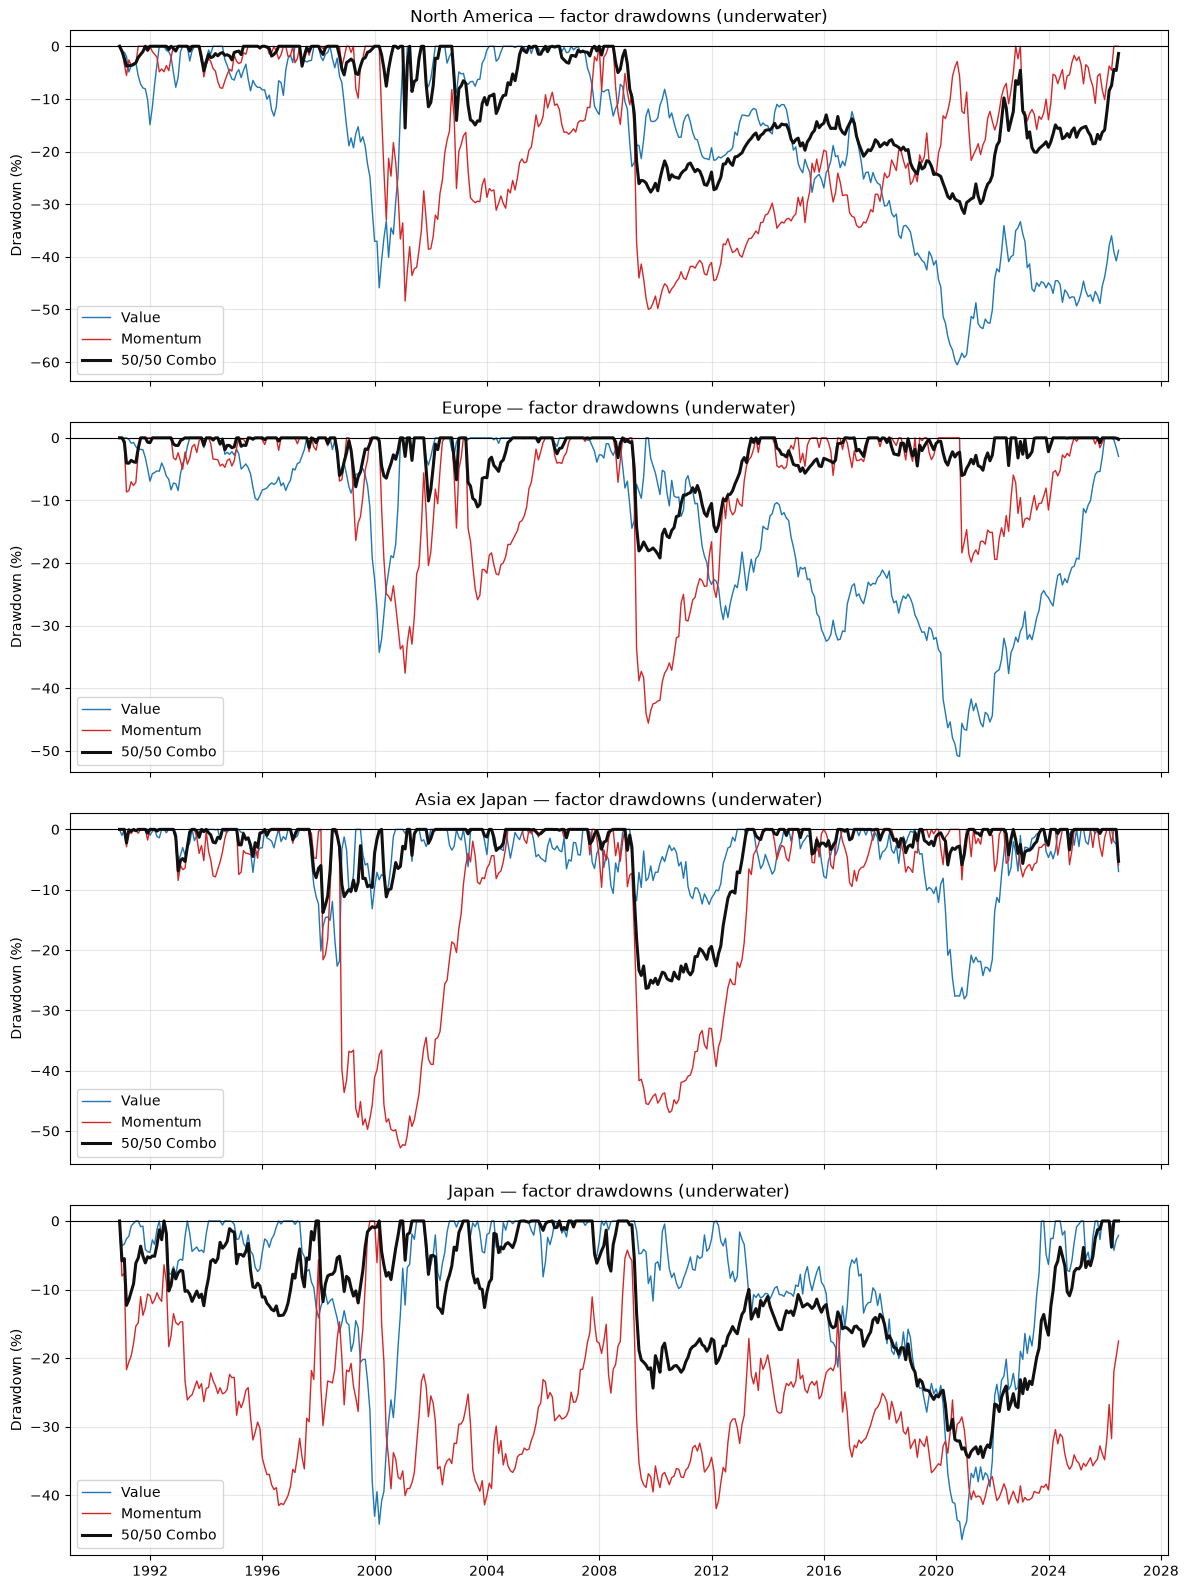

In [17]:
def drawdown(returns_pct: pd.Series) -> pd.Series:
    """Drawdown of the compounded equity curve vs its running peak, in %."""
    equity = (1 + returns_pct.dropna() / 100).cumprod()
    return (equity / equity.cummax() - 1) * 100


line_color = {"Value": "#1f77b4", "Momentum": "#d62728", "50/50 Combo": "#111111"}

fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

for ax, region_key in zip(axes, REGIONS):
    label = REGIONS[region_key]["label"]
    series = {
        "Value": panel[region_key]["Value"],
        "Momentum": panel[region_key]["Momentum"],
        "50/50 Combo": panel[region_key][["Value", "Momentum"]].mean(axis=1),
    }
    for name, returns in series.items():
        dd = drawdown(returns)
        width = 2.2 if name == "50/50 Combo" else 1.0
        ax.plot(dd.index, dd, label=name, color=line_color[name], linewidth=width)

    ax.set_title(f"{label} — factor drawdowns (underwater)")
    ax.set_ylabel("Drawdown (%)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.legend(loc="lower left")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Table 5: max drawdown (%) by factor and region, plus the combo's cushion vs its deeper leg.
def _max_dd(returns_pct: pd.Series) -> float:
    return drawdown(returns_pct).min()

table5 = pd.DataFrame(
    {
        "Value Max DD (%)": {REGIONS[rk]["label"]: _max_dd(panel[rk]["Value"]) for rk in REGIONS},
        "Momentum Max DD (%)": {REGIONS[rk]["label"]: _max_dd(panel[rk]["Momentum"]) for rk in REGIONS},
        "Combo Max DD (%)": {
            REGIONS[rk]["label"]: _max_dd(panel[rk][["Value", "Momentum"]].mean(axis=1)) for rk in REGIONS
        },
    }
)
# Positive = the combo's drawdown is shallower than the deeper (more negative) of the two legs.
table5["Combo vs Deeper Leg (pp)"] = (
    table5["Combo Max DD (%)"] - table5[["Value Max DD (%)", "Momentum Max DD (%)"]].min(axis=1)
)
table5.index.name = "Region"
table5.to_csv(DATA_DIR / "max_drawdown_table5.csv")
table5.round(1)